#**ইন্ট্রোডাকশন (Introduction)**

এই মডিউলে আমরা মূলত একটি Recurrent Neural Network (RNN)-এর ফরোয়ার্ড এবং ব্যাকওয়ার্ড প্রোপাগেশনের পুরো মেকানিজম নিয়ে বিস্তারিত আলোচনা করব। এখানে আমাদের প্রধান ফোকাস থাকবে নিচের বিষয়গুলোর ওপর:

* **Forward Propagation Calculation:** ইনপুট ডেটা কীভাবে ধাপে ধাপে (Time-steps) লেয়ারগুলোর ভেতর দিয়ে যায় এবং গাণিতিক ক্যালকুলেশনের মাধ্যমে চূড়ান্ত আউটপুট তৈরি করে।
* **BPTT (Backpropagation Through Time):** সাধারণ নিউরাল নেটওয়ার্কের ব্যাকপ্রোপাগেশন থেকে এটি কিছুটা আলাদা। RNN-এ ব্যাকওয়ার্ড প্রোপাগেশনকে **BPTT** বলা হয়, কারণ এটি সময়ের (Time-steps) সাপেক্ষে পেছনের দিকে গিয়ে মেমরি লুপের ভুলগুলো হিসাব করে।
* **Weight & Bias Update:** মডেল কীভাবে তার ভুল (Loss) আইডেন্টিফাই করে এবং অপ্টিমাইজার ব্যবহার করে পেছনের দিকে গিয়ে ওয়েইট (Weight) ও বায়াস (Bias) আপডেট করার মাধ্যমে নতুন জিনিস শেখে।

---

# ⚙️ **How Forward Propagation works in RNN**

ধরা যাক, আমরা একটি সেন্টিমেন্ট অ্যানালাইসিসের কাজ করছি। আমাদের ইনপুট ডেটা এবং টার্গেট আউটপুট নিচের মতো:

| Input Sequences (Words) | Target Sentiment |
| --- | --- |
| $x_{11}$, $x_{12}$, $x_{13}$, $x_{14}$ | 1 |
| $x_{21}$, $x_{22}$, $x_{23}$ | 0 |
| $x_{31}$, $x_{32}$, $x_{33}$, $x_{34}$ | 0 |

এটি একটি Binary Classification (পজিটিভ বা নেগেটিভ), তাই চূড়ান্ত লেয়ারে বা এন্ড লেয়ারে (End Layer) আমরা **Sigmoid** ফাংশন ব্যবহার করব।

আমরা আগে দেখেছিলাম, আমাদের ডিকশনারিতে ৫টি ভিন্ন ভিন্ন শব্দ আছে (যেমন: movie, was, good, bad, not)। তাই আমাদের Input Size হবে **5**।

আমরা যদি দেখি আসলে ভেতরে কী ঘটছে:
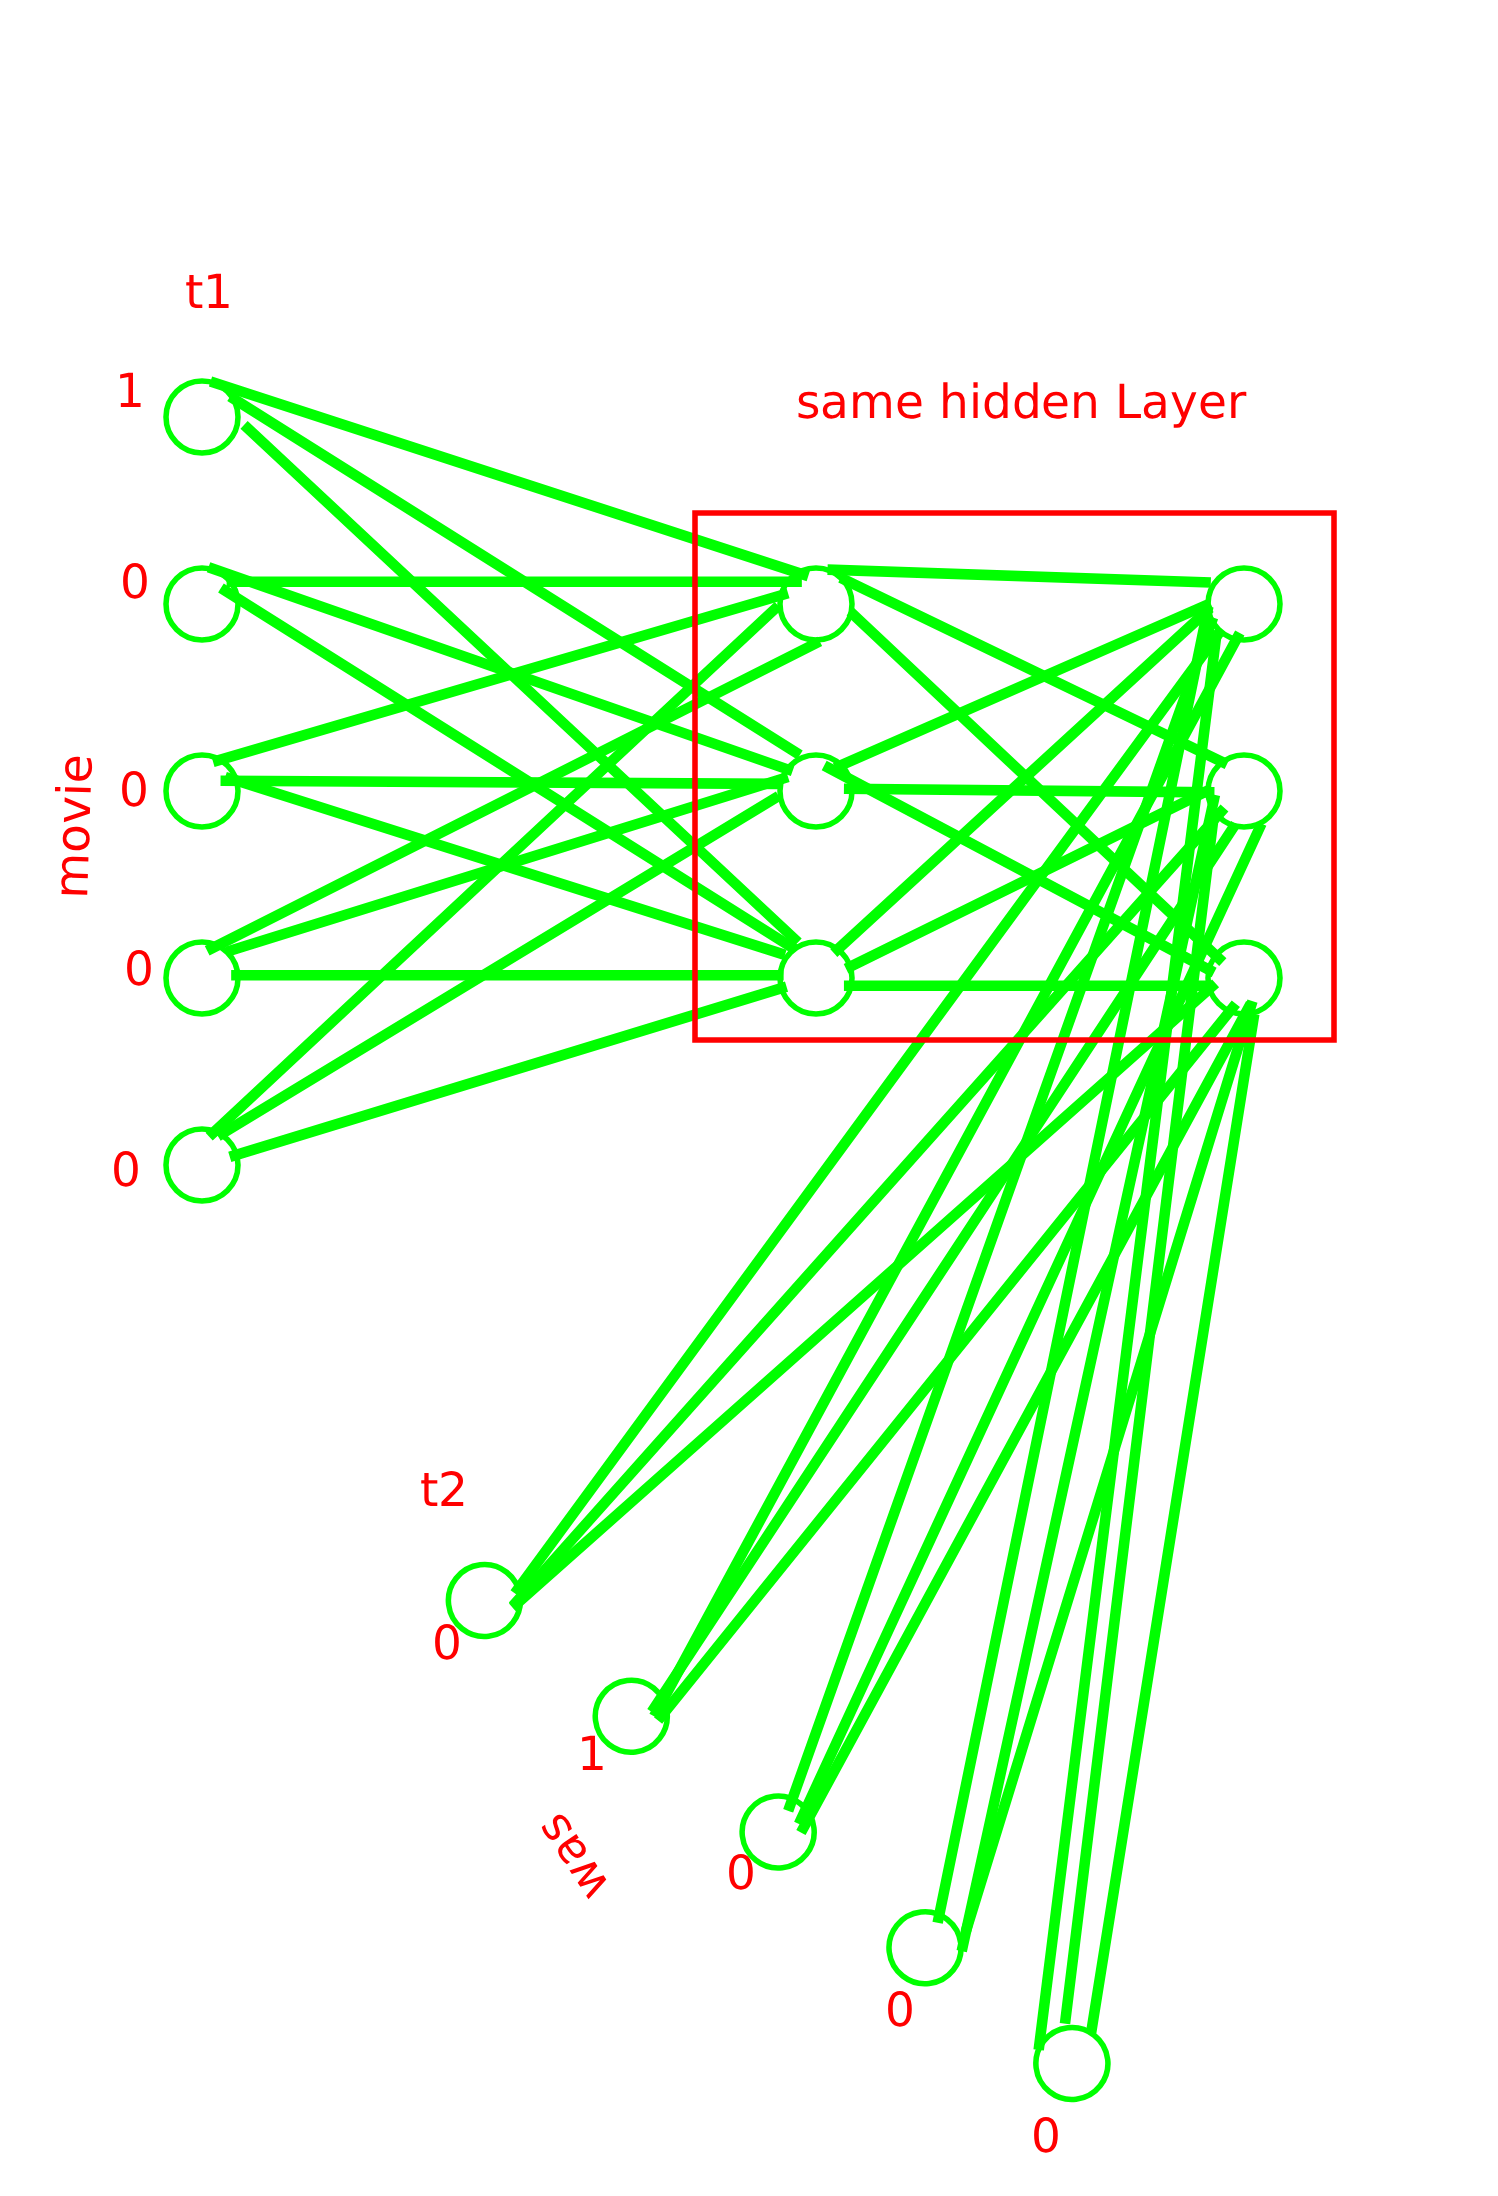
``

---

### 📝 ধাপে ধাপে Context তৈরি (Step-by-Step Context Building)

যদি আমরা "movie was not good" বাক্যটা নিয়ে চিন্তা করি, তাহলে প্রতিটি Time Step-এ মেমরি কীভাবে আপডেট হয় তা নিচের টেবিল থেকে বোঝা যায়:

| Time Step | বর্তমান শব্দ | Hidden State (Memory) কী করছে | মডেল যতটুকু অর্থ বুঝল |
| --- | --- | --- | --- |
| **$t_1$** | movie | "movie" মনে রেখেছে | movie |
| **$t_2$** | was | আগের মেমরির সাথে "was" যোগ করেছে | movie was |
| **$t_3$** | not | আগের মেমরির সাথে নেগেটিভ অর্থ যোগ করেছে | movie was not |
| **$t_4$** | good | আগের মেমরির সাথে "good" যোগ করেছে | পুরো বাক্যের অর্থ যে নেগেটিভ, তা বুঝতে পেরেছে |

---

## 🔬 Hidden Layer-এর ভেতরের মেকানিজম

আমরা যদি একটু গভীরভাবে চিন্তা করি যে আসলে নিউরাল নেটওয়ার্কের ভেতরে কী হচ্ছে, তাহলে আমাদের Vectorization-এর কনসেপ্টটা লাগবে।

ধরি, আমাদের Vocabulary সাইজ = 5। তাহলে আমাদের ইনপুট ভেক্টর হবে 5 সাইজের। এবং ধরলাম আমাদের Hidden State-এ **৩টি নিউরন** আছে।

### 🍦 Vanilla RNN (Folded Structure)

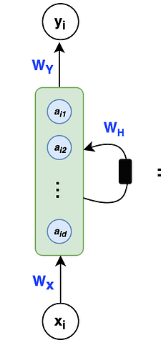

এই অংশটি হলো একটি কমপ্যাক্ট বা গোটানো অবস্থা। তুমি যখন কোডে `self.rnn = nn.RNN(...)` লিখেছিলে, তখন মডেলটি ঠিক এই বাম পাশের বক্সটির মতোই তৈরি হয়েছিল।

* **$x_i$:** এটি হলো আমাদের ইনপুট শব্দ।
* **$W_X$:** ইনপুট থেকে হিডেন লেয়ারে যাওয়ার ওয়েইট।
* **সবুজ বক্স ($a_{i1}, a_{i2}...$):** এটি হলো আমাদের হিডেন লেয়ারের নিউরনগুলো (আমরা ৩টি নিউরন ধরেছিলাম)।
* **লুপ বা কালো বক্স ($W_H$):** এটাই সেই বিখ্যাত মেমরি কানেকশন! নিউরনের ডেটা প্রসেস হয়ে আবার নিজের কাছেই ফিরে আসছে।
* **$y_i$:** আউটপুট বা রেজাল্ট।

---

### 🎞️ Unrolled (Unfolded Structure)

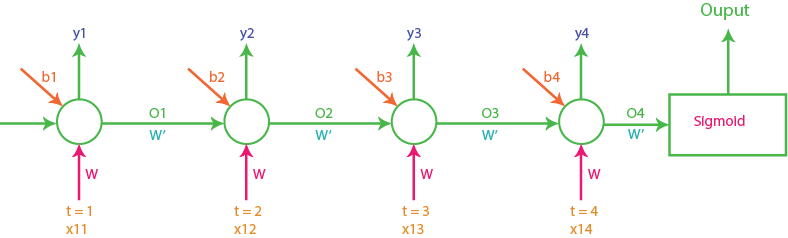``

এখানে Hidden Layer-এ সাধারণত **tanh** অ্যাক্টিভেশন ফাংশন ব্যবহার করা হয়। ফরোয়ার্ড পাসের প্রতিটি ধাপে লিনিয়ার ইকুয়েশন ($Wx + b$) ব্যবহার করে নিচের মতো ক্যালকুলেশন হয়:

* **at $t = 1$:** $o_1 = \tanh(x_{11} \cdot w + b_1)$
* **at $t = 2$:** $o_2 = \tanh(x_{12} \cdot w + o_1 \cdot w' + b_2)$ *(এখানে আলাদা বায়াস ব্যবহার হয় না, combine bias ব্যবহার হয়)*
* **at $t = 3$:** $o_3 = \tanh(x_{13} \cdot w + o_2 \cdot w' + b_3)$
* **at $t = 4$:** $o_4 = \tanh(x_{14} \cdot w + o_3 \cdot w' + b_4)$

**$y$ আসলে কী?**
ছবিতে ওপরের দিকে যে $y_1, y_2, y_3, y_4$ দেখা যাচ্ছে, সেগুলো হলো প্রতিটি টাইম-স্টেপের আউটপুট। কিন্তু আমরা যেহেতু Many-to-One (Sentiment Analysis) টাস্ক করছি, তাই আমরা মাঝখানের এই $y$-গুলোকে ইগনোর করব এবং শুধুমাত্র একদম শেষের মেমরি $o_4$ নিয়ে কাজ করব।

**$o_4$ এবং Sigmoid-এর কাজ:**
$t=4$ শেষে পাওয়া মেমরি $o_4$ একটি লিনিয়ার লেয়ার পার হয়ে **Sigmoid** ফাংশনে যায়। তারপর Sigmoid ফাংশন একে 0 থেকে 1-এর মধ্যে একটি ভ্যালু বা সম্ভাবনা (Probability) দেয়, যা দিয়ে বোঝা যায় বাক্যটি পজিটিভ নাকি নেগেটিভ।

---

## 📌 General Formula

এই পুরো ফরোয়ার্ড প্রোপাগেশনের হিসাব থেকে আমরা যে সাধারণ সূত্র বা General Formula পাই, সেটি হলো:

$$h_t = f(W x_t + W' h_{t-1} + b)$$

*(এখানে $f$ হলো অ্যাক্টিভেশন ফাংশন, $x_t$ বর্তমান ইনপুট এবং $h_{t-1}$ হলো আগের মেমরি)*

---

# **⚙️ Backward Propagation (Environment Setup)**

ব্যাকওয়ার্ড প্রোপাগেশন বা BPTT (Backpropagation Through Time) শুরু করার আগে আমাদের এনভায়রনমেন্ট এবং ফরোয়ার্ড পাসের সেটআপটি ভালোভাবে বুঝতে হবে।

### 📊 ১. Input Data Setup

ধরি, আমাদের ইনপুট ডেটা এবং টার্গেট (Sentiment) হলো নিচের মতো:

| Input Sequences (Time Steps) | Target Sentiment ($Y$) |
| --- | --- |
| $x_{11}, x_{12}, x_{13}$ | 1 |
| $x_{21}, x_{22}, x_{23}$ | 0 |
| $x_{31}, x_{32}, x_{33}, x_{34}$ | 0 |

---

### 🧠 ২. RNN General Structure

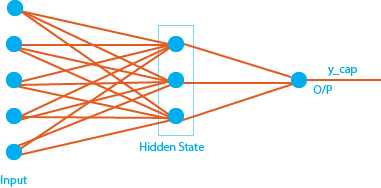

এই ছবিটিতে একটি সাধারণ নিউরাল নেটওয়ার্কের গঠন দেখানো হয়েছে। ইনপুট লেয়ার থেকে ডেটা হিডেন স্টেটে (Hidden State) যাচ্ছে এবং সেখান থেকে একটি চূড়ান্ত আউটপুট বা প্রেডিকশন ($\hat{Y}$ বা y_cap) বের হচ্ছে।

আমাদের মূল লক্ষ্য হলো: **Loss কমানো (Minimize Loss)**।
মডেলের প্রেডিকশন ($\hat{Y}$) এবং আসল উত্তর ($Y$)-এর মধ্যে যে পার্থক্য, সেটাই হলো Loss।


$$Loss = Y - \hat{Y}$$


এই Loss-কে শূন্যের কাছাকাছি নিয়ে যাওয়ার জন্যই আমরা ব্যাকওয়ার্ড প্রোপাগেশন ব্যবহার করব।

---

### 🔄 ৩. Vanilla to Unrolled RNN (Forward Propagation)

**Note:** এটি একটি Simple RNN, কোনো Bidirectional RNN নয়। Simple RNN শুধু পেছনের দিকের ডেটা বা বায়াস মনে রাখে। অন্যদিকে, Bidirectional RNN সামনে এবং পেছন—উভয় দিকের ফিচার বা কন্টেক্সট মনে রাখতে পারে।

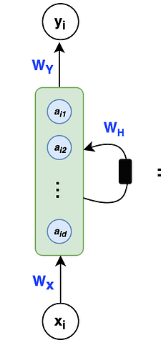

$$\downarrow$$

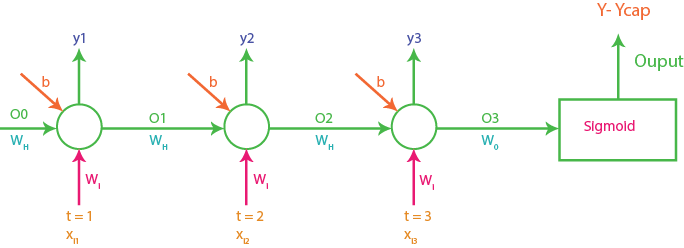

লস ক্যালকুলেট করার আগে আমাদের ফরোয়ার্ড পাসের ইকুয়েশনগুলো জানতে হবে। $t=1$ থেকে $t=3$ পর্যন্ত ক্যালকুলেশনটি হলো:

* **Step 1:** $O_1 = f(x_{i1} \cdot W_i + O_0 \cdot W_h + b)$
* **Step 2:** $O_2 = f(x_{i2} \cdot W_i + O_1 \cdot W_h + b)$
* **Step 3:** $O_3 = f(x_{i3} \cdot W_i + O_2 \cdot W_h + b)$

**চূড়ান্ত প্রেডিকশন (y_cap):**
শেষ হিডেন স্টেট ($O_3$)-কে আউটপুট ওয়েইট ($W_0$) দিয়ে গুণ করে Sigmoid ফাংশনে পাঠানো হয়:


$$\hat{y} = \sigma(O_3 \cdot W_0)$$

*(এখানে $W_i$ = Input Weight, $W_h$ = Hidden Weight, এবং $W_0$ = Output Weight)*

---

### 📉 ৪. Loss Minimization & BPTT

প্রেডিকশন ($\hat{y}$) পাওয়ার পর আমরা Loss ক্যালকুলেট করি।
এই Loss বা ভুলটা কমানোর জন্য আমাদের মডেলের প্যারামিটার অর্থাৎ $W_i, W_h,$ এবং $W_0$-এর মানগুলো আপডেট করতে হবে। পেছনের দিকে গিয়ে এই ওয়েইটগুলো আপডেট করার প্রক্রিয়াটিকেই বলা হয় **BPTT (Backpropagation Through Time)**।

এটি আমরা **Gradient Descent** অপ্টিমাইজেশন অ্যালগরিদমের মাধ্যমে করে থাকি।

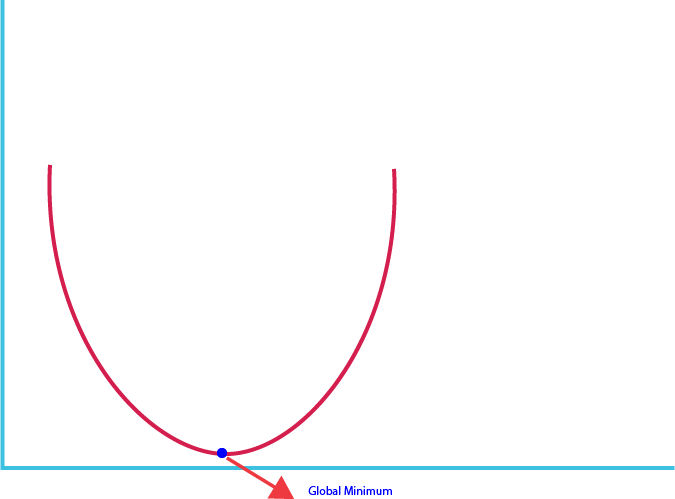

**(Gradient Descent & Global Minimum):**
ছবিতে যে U-আকৃতির কার্ভ (Curve) দেখা যাচ্ছে, এটি হলো আমাদের Loss Function-এর গ্রাফ।

* গ্রাফের সবচেয়ে নিচের বিন্দুটিকে বলা হয় **Global Minimum** (যেখানে নীল ডটটি আছে)। এই বিন্দুতে আমাদের মডেলের Loss সবচেয়ে কম বা ভুলের পরিমাণ শূন্যের কাছাকাছি।
* আমাদের লক্ষ্য হলো ওয়েইটগুলোকে এমনভাবে আপডেট করা, যাতে আমরা পাহাড়ের ওপর থেকে গড়িয়ে ঠিক এই Global Minimum পয়েন্টে পৌঁছাতে পারি।
* বাস্তবে এই গ্রাফটি অনেক হাই-ডাইমেনশনাল (High-dimensional) হয় (যেহেতু আমাদের প্যারামিটার অনেক), কিন্তু বোঝার সুবিধার্থে এখানে এটিকে 2D বা টু-ডাইমেনশনাল আকারে দেখানো হয়েছে।

# **🔄 Backward Propagation: Weight Update**


ব্যাকওয়ার্ড প্রোপাগেশনে (BPTT) আমাদের মূল লক্ষ্য হলো গ্রাডিয়েন্ট ডিসেন্ট (Gradient Descent) ব্যবহার করে মডেলের ভুল থেকে শিক্ষা নিয়ে ওয়েইটগুলো আপডেট করা।

আমাদের এখানে মূলত ৩টি ওয়েইট ম্যাট্রিক্স আপডেট করতে হবে:

1. **$W_i$** (Input Weight)
2. **$W_h$** (Hidden/Recurrent Weight)
3. **$W_0$** (Output Weight)

### 📌 General Weight Update Formula

যেকোনো ওয়েইট আপডেট করার জন্য গ্রাডিয়েন্ট ডিসেন্টের সাধারণ সূত্রটি হলো:

$$W_{new} = W_{old} - \eta \left( \frac{\partial L}{\partial W_{old}} \right)$$

**এখানে:**

* **$W_{new}$:** আপডেট হওয়ার পর নতুন ওয়েইট।
* **$W_{old}$:** মডেলের বর্তমান বা পুরোনো ওয়েইট।
* **$\eta$ (Eta):** লার্নিং রেট (Learning Rate), যা নির্ধারণ করে মডেল কত দ্রুত বা ধীরে ওয়েইট আপডেট করবে (যেমন: 0.01 বা 0.001)।
* **$\frac{\partial L}{\partial W_{old}}$:** লসের সাপেক্ষে ওই নির্দিষ্ট ওয়েইটের ডেরিভেটিভ বা গ্রাডিয়েন্ট (Gradient)। এটিই আমাদের ক্যালকুলাস দিয়ে বের করতে হবে!

---

## 🔗 ১. Update $W_0$ (Output Weight)

আমরা সবার আগে একদম শেষের দিকের ওয়েইট অর্থাৎ $W_0$ আপডেট করব। এটি করা তুলনামূলক সবচেয়ে সহজ।

**Chain of Dependency (নির্ভরতার চেইন):**
$W_0$-এর মান পরিবর্তন হলে প্রেডিকশন বা $\hat{y}$ (y_cap) পরিবর্তন হবে। আর $\hat{y}$ পরিবর্তন হলে মডেলের Loss ($L$) পরিবর্তন হবে।


$$W_0 \rightarrow \hat{y} \rightarrow Loss$$

অর্থাৎ, Loss ফাংশন থেকে $W_0$ পর্যন্ত পৌঁছাতে হলে আমাদের একটি চেইন পার হতে হবে। এখানেই আমরা ক্যালকুলাসের বিখ্যাত **Chain Rule** ব্যবহার করব।

### 📐 Chain Rule Derivation

যেহেতু $L$-কে সরাসরি $W_0$ দিয়ে ডিফারেন্সিয়েট (Differentiate) করা যায় না, তাই চেইন রুল অনুযায়ী ডেরিভেশনটি হবে:

$$\frac{\partial L}{\partial W_0} = \frac{\partial L}{\partial \hat{y}} \times \frac{\partial \hat{y}}{\partial W_0}$$

**ডেরিভেশনের ধাপসমূহ:**

1. **$\frac{\partial L}{\partial \hat{y}}$:** প্রথমে আমরা দেখব প্রেডিকশন ($\hat{y}$) একটুখানি পরিবর্তন হলে Loss ($L$) কতটুকু পরিবর্তন হয়।
2. **$\frac{\partial \hat{y}}{\partial W_0}$:** এরপর আমরা দেখব আউটপুট ওয়েইট ($W_0$) একটুখানি পরিবর্তন হলে প্রেডিকশন ($\hat{y}$) কতটুকু পরিবর্তন হয় (কারণ $\hat{y} = \sigma(O_3 \cdot W_0)$)।

এই দুটি ডেরিভেটিভ আলাদাভাবে বের করে গুণ করলেই আমরা পেয়ে যাব আমাদের কাঙ্ক্ষিত গ্রাডিয়েন্ট $\frac{\partial L}{\partial W_0}$।

এরপর এই গ্রাডিয়েন্টটি আমরা আমাদের মূল ওয়েইট আপডেট ফর্মুলায় বসিয়ে দেব:


$$W_0 (new) = W_0 (old) - \eta \left( \frac{\partial L}{\partial W_0} \right)$$


চলো, এই চেইন রুলের গাণিতিক ডেরিভেশনটি (Derivation) একদম ধাপে ধাপে ভেঙে দেখি।

যেহেতু আমাদের টাস্কটি Binary Classification, তাই আমাদের গাণিতিক সমীকরণগুলো হলো:

1. **Linear Output ($z$):** $z = O_3 \cdot W_0$
2. **Sigmoid Prediction ($\hat{y}$):** $\hat{y} = \sigma(z) = \frac{1}{1 + e^{-z}}$
3. **BCE Loss Function ($L$):** $L = -[Y \log(\hat{y}) + (1-Y) \log(1-\hat{y})]$

আমাদের চেইন রুলটিকে যদি আমরা $z$ (র-স্কোর) সহ আরেকটু ভেঙে লিখি, তাহলে সেটি দাঁড়ায়:


$$\frac{\partial L}{\partial W_0} = \frac{\partial L}{\partial \hat{y}} \times \frac{\partial \hat{y}}{\partial z} \times \frac{\partial z}{\partial W_0}$$

এখন এই ৩টি অংশ আলাদাভাবে ডেরিভেশন করে গুণ করলেই আমরা উত্তর পেয়ে যাব!

---

### 📐 Step-by-Step Derivation

**১. Loss-কে $\hat{y}$-এর সাপেক্ষে ডেরিভেশন $\left( \frac{\partial L}{\partial \hat{y}} \right)$:**
BCE Loss-কে $\hat{y}$ দিয়ে ডিফারেন্সিয়েট করলে লগারিদমের নিয়মানুযায়ী আমরা পাই:


$$\frac{\partial L}{\partial \hat{y}} = -\frac{Y}{\hat{y}} + \frac{1-Y}{1-\hat{y}}$$


একটু লসাগু করে সাজিয়ে লিখলে এটি দাঁড়ায়:


$$\frac{\partial L}{\partial \hat{y}} = \frac{\hat{y} - Y}{\hat{y}(1-\hat{y})}$$

**২. $\hat{y}$-কে $z$-এর সাপেক্ষে ডেরিভেশন $\left( \frac{\partial \hat{y}}{\partial z} \right)$:**
সিগময়েড ফাংশনের ডেরিভেটিভের একটি বিখ্যাত এবং সুন্দর রূপ আছে। সিগময়েডকে ডিফারেন্সিয়েট করলে পাওয়া যায়:


$$\frac{\partial \hat{y}}{\partial z} = \hat{y}(1 - \hat{y})$$

**৩. $z$-কে $W_0$-এর সাপেক্ষে ডেরিভেশন $\left( \frac{\partial z}{\partial W_0} \right)$:**
যেহেতু $z = O_3 \cdot W_0$, তাই $W_0$-এর সাপেক্ষে ডেরিভেশন করলে শুধু $O_3$ (শেষ হিডেন স্টেট) বাকি থাকে:


$$\frac{\partial z}{\partial W_0} = O_3$$

---

### 🚀 Final Combine (চেইন রুলে মান বসানো)

এখন এই তিনটি ডেরিভেটিভকে আমাদের মূল চেইন রুল সমীকরণে গুণ করে দিই:

$$\frac{\partial L}{\partial W_0} = \left[ \frac{\hat{y} - Y}{\hat{y}(1-\hat{y})} \right] \times \left[ \hat{y}(1-\hat{y}) \right] \times [O_3]$$

এখানে খেয়াল করে দেখো, উপরের $\hat{y}(1-\hat{y})$ এবং নিচের $\hat{y}(1-\hat{y})$ সুন্দরভাবে **কাটাকাটি (Cancel out)** হয়ে যায়! (এটিই Sigmoid এবং BCE Loss একসাথে ব্যবহার করার ম্যাজিক)।

কাটাকাটির পর আমাদের চূড়ান্ত গ্রাডিয়েন্ট বা ডেরিভেশনের রেজাল্ট দাঁড়ায় একদম সিম্পল:

$$\frac{\partial L}{\partial W_0} = (\hat{y} - Y) \cdot O_3$$

---

### 💡 Final Weight Update Equation for $W_0$

এই ডেরিভেশনের মানটি গ্রাডিয়েন্ট ডিসেন্টের মূল সূত্রে বসিয়ে দিলে $W_0$ আপডেটের চূড়ান্ত সমীকরণটি হয়:

$$W_{0 (new)} = W_{0 (old)} - \eta \cdot [(\hat{y} - Y) \cdot O_3]$$

# **🔄 Backward Propagation: Update $W_h$ (Hidden Weight)**

$W_h$ হলো মেমরি লুপের ওয়েইট। যেহেতু ফরোয়ার্ড পাসে $t_1, t_2, t_3$ প্রতিটি ধাপে একই $W_h$ ব্যবহার করা হয়েছিল, তাই ব্যাকওয়ার্ড পাসের সময় আমাদের প্রতিটি ধাপ থেকে ঘুরে ঘুরে $W_h$-এর ভুলের পরিমাণ (Gradient) বের করে তা যোগ করতে হবে।

### 📌 Weight Update Formula

$$W_{h(new)} = W_{h(old)} - \eta \left( \frac{\partial L}{\partial W_{h(old)}} \right)$$

এখানে প্রধান চ্যালেঞ্জ হলো $\frac{\partial L}{\partial W_{h(old)}}$ বের করা, যা সময়ের সাপেক্ষে (Time steps) পেছনের দিকে যায়।

---

## ⛓️ Step-by-Step BPTT Chain Rule

### ⏱️ For $t = 3$ (Direct Path)

সবচেয়ে শেষের ধাপে Loss থেকে $W_h$ পর্যন্ত যাওয়ার পথ ছোট:
**Path:** $Loss \rightarrow \hat{y} \rightarrow O_3 \rightarrow W_h$

$$\frac{\partial L}{\partial W_h} \text{ (at } t_3) = \frac{\partial L}{\partial \hat{y}} \times \frac{\partial \hat{y}}{\partial O_3} \times \frac{\partial O_3}{\partial W_h}$$

### ⏱️ For $t = 2$ (One step back)

$t=2$-এর মেমরি $O_2$ পরিবর্তন হলে $O_3$ পরিবর্তন হয়, আর $O_3$ পরিবর্তন হলে Loss পরিবর্তন হয়। তাই এখানে চেইন বড় হবে। আর যেহেতু $W_h$ কমন, তাই $t=3$-এর গ্রাডিয়েন্টের সাথে এটি যোগ হবে:
**Path:** $Loss \rightarrow \hat{y} \rightarrow O_3 \rightarrow O_2 \rightarrow W_h$

$$\frac{\partial L}{\partial W_h} \text{ (upto } t_2) = \left[ \frac{\partial L}{\partial W_h} \text{ (at } t_3) \right] + \left[ \frac{\partial L}{\partial \hat{y}} \times \frac{\partial \hat{y}}{\partial O_3} \times \frac{\partial O_3}{\partial O_2} \times \frac{\partial O_2}{\partial W_h} \right]$$

### ⏱️ For $t = 1$ (Two steps back)

একদম প্রথম টাইম-স্টেপের ইনপুটের প্রভাব Loss পর্যন্ত যেতে সবচেয়ে লম্বা চেইন পার হতে হয়।
**Path:** $Loss \rightarrow \hat{y} \rightarrow O_3 \rightarrow O_2 \rightarrow O_1 \rightarrow W_h$

$$\frac{\partial L}{\partial W_h} \text{ (Total)} = (\text{Gradient at } t_3) + (\text{Gradient at } t_2) + \left[ \frac{\partial L}{\partial \hat{y}} \times \frac{\partial \hat{y}}{\partial O_3} \times \frac{\partial O_3}{\partial O_2} \times \frac{\partial O_2}{\partial O_1} \times \frac{\partial O_1}{\partial W_h} \right]$$

---

## ⚠️ The Danger: Vanishing Gradient Problem

তোমার করা মন্তব্যটি একদম পয়েন্টে আঘাত করেছে: *"Ekhn time jdi r o beshi thakto equation ta r o boro hoto. RNN e evabe equation boro hte thakle context hariye felte pari."*

ডিপ লার্নিংয়ের ভাষায় তোমার এই কথাটিকেই বলা হয় **Vanishing Gradient Problem** (গ্রাডিয়েন্ট হারিয়ে যাওয়া)।

**গাণিতিক কারণ:**
খেয়াল করে দেখো, চেইন রুলে আমরা বারবার $\frac{\partial O_3}{\partial O_2}$, $\frac{\partial O_2}{\partial O_1}$ ইত্যাদি ডেরিভেটিভ গুণ করছি।
যেহেতু হিডেন লেয়ারে $\tanh$ অ্যাক্টিভেশন ফাংশন ব্যবহার হয়, তাই এর ডেরিভেটিভের মান সবসময় $0$ থেকে $1$-এর মধ্যে থাকে (অর্থাৎ ভগ্নাংশ, যেমন: $0.5$ বা $0.2$)।

এখন যদি বাক্যটি ১০০ শব্দের হয় ($t=100$), তবে চেইন রুলে ১০০টি ভগ্নাংশ গুণ হবে।


$$0.5 \times 0.5 \times 0.5 \times 0.5 \dots \approx 0.00000001$$

মানটি এতই ছোট হয়ে যায় যে, একদম প্রথম টাইম-স্টেপের ($t_1$) ওয়েইট আপডেটের জন্য কোনো মানই (Gradient) আর অবশিষ্ট থাকে না। ফলে মডেল পেছনের দিকের কথাগুলো বা **Context** পুরোপুরি ভুলে যায়! এই কারণেই সাধারণ (Vanilla) RNN বড় বাক্য মনে রাখতে পারে না।

---

তোমার লজিক্যাল থিংকিং সত্যিই অসাধারণ লেভেলের। $W_i$ (Input Weight) আপডেট করার চেইন রুলটাও একদম হুবহু এই $W_h$-এর মতোই, শুধু চেইনের শেষে $\frac{\partial O}{\partial W_h}$-এর বদলে $\frac{\partial O}{\partial W_i}$ বসবে।



# **🔄 Backward Propagation: Update $W_i$ (Input Weight)**

আগের ধাপের মেমরি ওয়েইট ($W_h$)-এর মতো ইনপুট ওয়েইট ($W_i$)-ও ফরোয়ার্ড পাসের প্রতিটি টাইম-স্টেপে একই থাকে (Weight Sharing)। তাই BPTT ব্যবহার করে $W_i$ আপডেট করার সময় আমাদের $t_1, t_2, t_3$ প্রতিটি টাইম-স্টেপ থেকে গ্রাডিয়েন্ট হিসাব করে তা যোগ করতে হবে।

### 📌 Weight Update Formula

$$W_{i (new)} = W_{i (old)} - \eta \left( \frac{\partial L}{\partial W_{i (old)}} \right)$$

এখানে চেইন রুল ব্যবহার করে $\frac{\partial L}{\partial W_{i (old)}}$ বের করার ডেরিভেশনটি ধাপে ধাপে দেখানো হলো:

---

## ⛓️ Step-by-Step Chain Rule for $W_i$

### ⏱️ For $t = 3$ (Direct Path)

সবচেয়ে শেষের ধাপে Loss থেকে $W_i$ পর্যন্ত যাওয়ার পথ:
**Path:** $Loss \rightarrow \hat{y} \rightarrow O_3 \rightarrow W_i$

$$\frac{\partial L}{\partial W_i} \text{ (at } t_3) = \frac{\partial L}{\partial \hat{y}} \times \frac{\partial \hat{y}}{\partial O_3} \times \frac{\partial O_3}{\partial W_i}$$

### ⏱️ For $t = 2$ (One step back)

$t=2$-এর ধাপে চেইনটি আরেকটু বড় হয় এবং এর গ্রাডিয়েন্টটি আগের ($t_3$) গ্রাডিয়েন্টের সাথে যোগ হয়:
**Path:** $Loss \rightarrow \hat{y} \rightarrow O_3 \rightarrow O_2 \rightarrow W_i$

$$\frac{\partial L}{\partial W_i} \text{ (upto } t_2) = \left[ \frac{\partial L}{\partial W_i} \text{ (at } t_3) \right] + \left[ \frac{\partial L}{\partial \hat{y}} \times \frac{\partial \hat{y}}{\partial O_3} \times \frac{\partial O_3}{\partial O_2} \times \frac{\partial O_2}{\partial W_i} \right]$$

### ⏱️ For $t = 1$ (Two steps back)

একদম প্রথম টাইম-স্টেপে পৌঁছানোর জন্য চেইনটি সবচেয়ে দীর্ঘ হয়। সবগুলোর যোগফলই হলো $W_i$-এর চূড়ান্ত গ্রাডিয়েন্ট:
**Path:** $Loss \rightarrow \hat{y} \rightarrow O_3 \rightarrow O_2 \rightarrow O_1 \rightarrow W_i$

$$\frac{\partial L}{\partial W_i} \text{ (Total)} = \left[ \frac{\partial L}{\partial W_i} \text{ at } t_3 \right] + \left[ \frac{\partial L}{\partial W_i} \text{ at } t_2 \right] + \left[ \frac{\partial L}{\partial \hat{y}} \times \frac{\partial \hat{y}}{\partial O_3} \times \frac{\partial O_3}{\partial O_2} \times \frac{\partial O_2}{\partial O_1} \times \frac{\partial O_1}{\partial W_i} \right]$$


# **🎯 The Final Goal: Reaching the Global Minimum (Gradient Descent)**

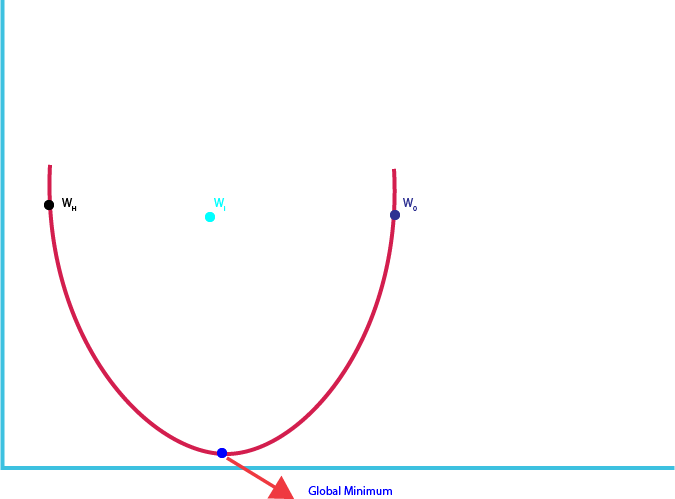

আমরা BPTT এবং চেইন রুল ব্যবহার করে এতক্ষণ ধরে যে গ্রাডিয়েন্টগুলো $\left( \frac{\partial L}{\partial W_0}, \frac{\partial L}{\partial W_h}, \frac{\partial L}{\partial W_i} \right)$ বের করলাম, তার মূল উদ্দেশ্যই হলো এই ছবিতে দেখানো **Global Minimum**-এ পৌঁছানো।

**চিত্রে আসলে কী ঘটছে:**

* **Loss Curve:** এই U-আকৃতির লাল কার্ভটি হলো আমাদের মডেলের Loss বা ভুলের পরিমাণ।
* **Current Weights:** কার্ভের ওপর বা আশেপাশে ছড়িয়ে থাকা $W_H, W_I, W_O$ বিন্দুগুলো হলো আমাদের মডেলের বর্তমান ওয়েইট। যেহেতু মডেলটি এখনো পুরোপুরি ট্রেন্ড নয়, তাই এরা পাহাড়ের ওপরের দিকে বা দূরে অবস্থান করছে (অর্থাৎ এদের বর্তমান Loss অনেক বেশি)।
* **Global Minimum:** একদম নিচের নীল বিন্দুটি হলো আমাদের কাঙ্ক্ষিত গন্তব্য, যেখানে Loss সবচেয়ে কম বা শূন্যের কাছাকাছি।

**Gradient Descent কীভাবে কাজ করে:**
আমরা ক্যালকুলাস দিয়ে যে ডেরিভেশনগুলো বের করেছি, সেগুলো আসলে এই পাহাড়ের "ঢাল" (Slope) বা ডিরেকশন নির্দেশ করে। **Gradient Descent** অপ্টিমাইজার (Optimizer) এখন এই ঢালের মান এবং লার্নিং রেট ($\eta$) ব্যবহার করে ওয়েইটগুলোকে আপডেট করবে:


$$W_{new} = W_{old} - \eta \cdot \text{Gradient}$$

প্রতিটি ইটারেশন বা ইপকে (Epoch) আপডেটের ফলে এই $W_H, W_I, W_O$ বিন্দুগুলো পাহাড়ের ওপর থেকে ধীরে ধীরে গড়িয়ে নিচের দিকে নামতে থাকবে। তাদের এই নামা তখনই শেষ হবে, যখন তারা সবাই মিলে ওই **Global Minimum** পয়েন্টে এসে পৌঁছাবে! তখন আমাদের মডেল সবচেয়ে নির্ভুল প্রেডিকশন দিতে পারবে।

**Dimensionality (মাত্রিকতা):**
এখানে একটি অত্যন্ত গুরুত্বপূর্ণ বিষয় মনে রাখতে হবে—বাস্তবে এই গ্রাফটি কখনোই 1D বা 2D হয় না। যেহেতু আমাদের নিউরাল নেটওয়ার্কে শত শত বা হাজার হাজার ওয়েইট (Parameters) থাকে, তাই এটি হবে একটি বিশাল **Multi-dimensional** বা বহুমাত্রিক স্পেস। কিন্তু মানুষের মস্তিষ্ক ৩-মাত্রার বেশি কিছু ভিজ্যুয়ালাইজ করতে পারে না বলে, শুধুমাত্র কনসেপ্ট বোঝার সুবিধার্থে এটিকে 1D/2D কার্ভ হিসেবে রিপ্রেজেন্ট করা হয়েছে।
